# Example-28: Additional frequency processing

In [1]:
# In this example frequency and noise are computed for signals and samples
# Noise is used for weighting (or SNR)
# Weighted mean and variance are compared with regular mean and variance
# Outlies (signals or samples) are detected using different dispersion estimations
# Dispersion can be estimated with variance, weighted variance, biweight midvariance or interquatile range
# Data points outside given threshold (scaled dispersion) are considered to be outliers

# Different center and dispersion estimators are defined in harmonica.statistics
# Including trimmed and winsorized variants for mean and variance (not used in this example)

# Note, biweight midvariance or interquatile range are robust dispersion estimators, can be used when weights are not avalible

In [2]:
# Import

import epics
import numpy
import pandas
import torch
import nufft

import sys
sys.path.append('..')

from harmonica.util import LENGTH, make_mark, make_mask

from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter

from harmonica.statistics import mean, variance
from harmonica.statistics import weighted_mean, weighted_variance
from harmonica.statistics import median, biweight_midvariance
from harmonica.statistics import quantile, quartiles, interquartile_range, whiskers

from harmonica.anomaly import threshold

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())
print(torch.get_num_threads())

True
16


In [3]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

In [4]:
# Reference case

# Set parameters

length = 1024

# Set window

w = Window(length, 'cosine_window', 5.0, dtype=dtype, device=device)

# Load TbT

d = Data.from_file(54, w, '../virtual_tbt.npy')

# Remove mean and apply window

d.window_remove_mean()
d.window_apply()

# Compute reference frequency

f = Frequency(d)
f('parabola')
f_ref, s_ref = f.frequency.mean().cpu().item(), f.frequency.std().cpu().item()

# Reset work

d.reset()

# Print results

print(f'{f_ref:<16.9}')
print(f'{s_ref:<16.9}')

0.463116901     
2.30523602e-16  


In [5]:
# Set data with noise

# Generate noise sigma for each signal

std = 1.0E-6*(25.0 + 75.0*torch.rand(54, dtype=dtype, device=device))

# Set test data

d.reset()
d.add_noise(std)
data = d.work
print(data.shape)

# Set spike

data[1, 128] += 0.5
data[1, 256] -= 0.5
data[25, 128] += 0.25
data[25, 256] -= 0.25

torch.Size([54, 1024])


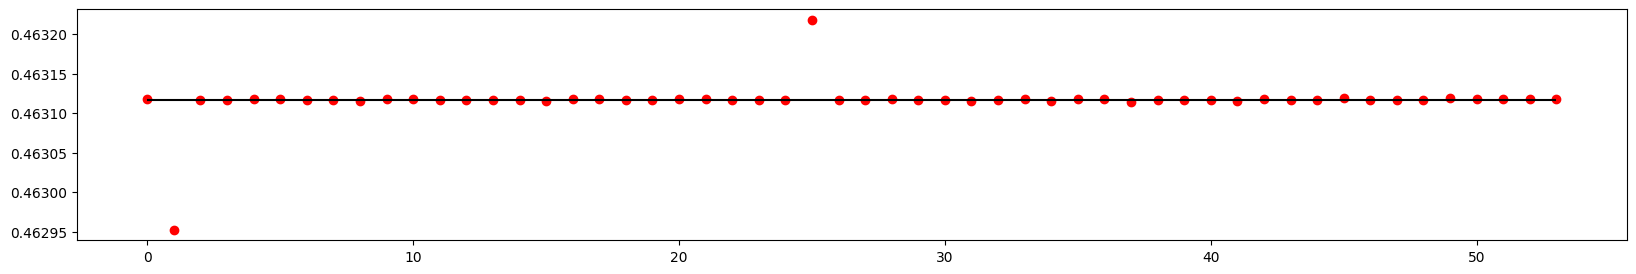

err: 1.13170224e-06  , std: 2.6525557e-05   
err: 6.30276561e-08  , std: 6.62918024e-07  


In [6]:
# Estimate the main frequency for each signal using 'parabola' interpolation of refined amplitude spectrum
# Estimate noise for each signal using optimal SVD

# Set data

w = Window(length, 'cosine_window', 1.0, dtype=dtype, device=device)
t = Data.from_data(w, data)

# Estimate noise

l = Filter(t)
_, s = l.estimate_noise(limit=32)

# Estimate frequency

t.window_remove_mean()
t.window_apply()
f = Frequency(t)
f('parabola')
t.reset()

# Set weight

weight = 1.0/s**2*torch.stack([spectrum[index] for index, spectrum in zip(f.ffrft_bin.to(torch.int64), f.ffrft_spectrum)])**2

# Plot frequencies for each signal

plt.figure(figsize=(20, 3))
plt.scatter(range(f.size), f.frequency.cpu().numpy(), color='red', marker='o')
plt.hlines(f_ref, 0, f.size - 1, color='black')
plt.show()

# Mean & variance

f_out = mean(f.frequency)
s_out = variance(f.frequency).sqrt()
print(f'err: {abs(f_out - f_ref):<16.9}, std: {s_out:<16.9}')

# Weighted mean & variance

f_out = weighted_mean(f.frequency, weight=weight)
s_out = weighted_variance(f.frequency, weight=weight).sqrt()
print(f'err: {abs(f_out - f_ref):<16.9}, std: {s_out:<16.9}')

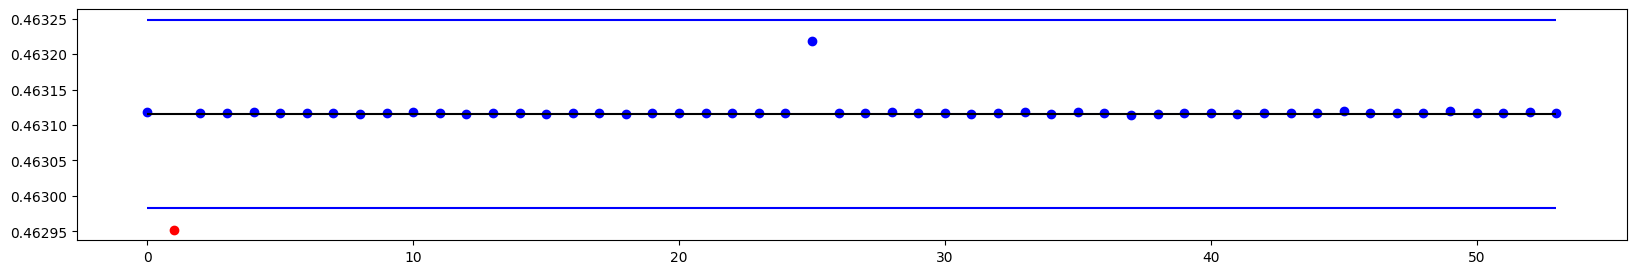

err: 1.9521505e-06   , std: 1.39180509e-05  
err: 6.30352197e-08  , std: 6.61934768e-07  


In [7]:
# Use mean and variance to remove outliers

time = torch.tensor(range(f.size), dtype=dtype, device=device)

factor = 5.0
center = mean(f.frequency)
spread = factor*variance(f.frequency).sqrt()
min_value, max_value = center - spread, center + spread
mask = threshold(f.frequency, min_value, max_value).squeeze(0)

plt.figure(figsize=(20, 3))
plt.scatter(time[~mask].cpu().numpy(), f.frequency[~mask].cpu().numpy(), color='red', marker='o')
plt.scatter(time[mask].cpu().numpy(), f.frequency[mask].cpu().numpy(), color='blue', marker='o')
plt.hlines(center.cpu().numpy(), 0, f.size - 1, color='black')
plt.hlines(center.cpu().numpy() - spread.cpu().numpy(), 0, f.size - 1, color='blue')
plt.hlines(center.cpu().numpy() + spread.cpu().numpy(), 0, f.size - 1, color='blue')
plt.show()

# Mean & variance

f_out = mean(f.frequency[mask])
s_out = variance(f.frequency[mask]).sqrt()
print(f'err: {abs(f_out - f_ref):<16.9}, std: {s_out:<16.9}')

# Weighted mean & variance

weight = 1.0/s**2*torch.stack([spectrum[index] for index, spectrum in zip(f.ffrft_bin.to(torch.int64), f.ffrft_spectrum)])**2
f_out = weighted_mean(f.frequency, weight=weight*mask)
s_out = weighted_variance(f.frequency, weight=weight*mask).sqrt()
print(f'err: {abs(f_out - f_ref):<16.9}, std: {s_out:<16.9}')

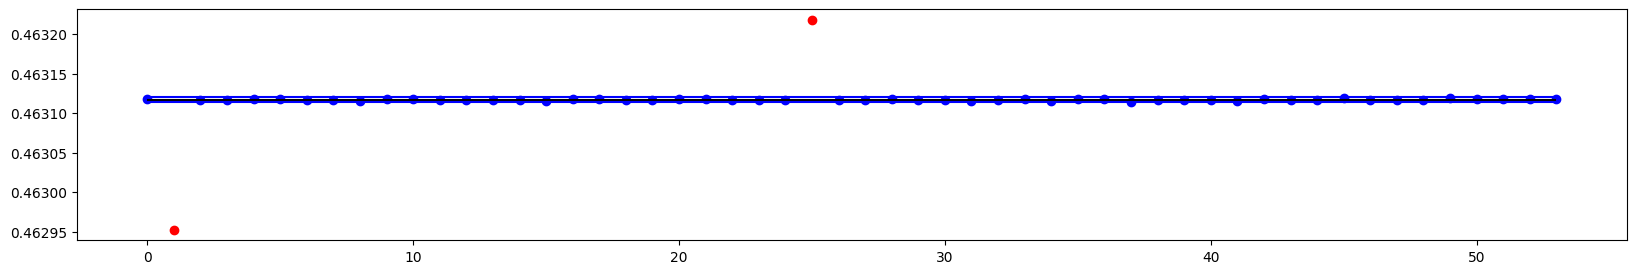

err: 4.48514215e-08  , std: 9.62865848e-07  
err: 6.2949026e-08   , std: 6.55015161e-07  


In [8]:
# Use weighted mean and variance to remove outliers

time = torch.tensor(range(f.size), dtype=dtype, device=device)

factor = 5.0
center = weighted_mean(f.frequency, weight=weight)
spread = factor*weighted_variance(f.frequency, weight=weight).sqrt()
min_value, max_value = center - spread, center + spread
mask = threshold(f.frequency, min_value, max_value).squeeze(0)

plt.figure(figsize=(20, 3))
plt.scatter(time[~mask].cpu().numpy(), f.frequency[~mask].cpu().numpy(), color='red', marker='o')
plt.scatter(time[mask].cpu().numpy(), f.frequency[mask].cpu().numpy(), color='blue', marker='o')
plt.hlines(center.cpu().numpy(), 0, f.size - 1, color='black')
plt.hlines(center.cpu().numpy() - spread.cpu().numpy(), 0, f.size - 1, color='blue')
plt.hlines(center.cpu().numpy() + spread.cpu().numpy(), 0, f.size - 1, color='blue')
plt.show()

# Mean & variance

f_out = mean(f.frequency[mask])
s_out = variance(f.frequency[mask]).sqrt()
print(f'err: {abs(f_out - f_ref):<16.9}, std: {s_out:<16.9}')

# Weighted mean & variance

weight = 1.0/s**2*torch.stack([spectrum[index] for index, spectrum in zip(f.ffrft_bin.to(torch.int64), f.ffrft_spectrum)])**2
f_out = weighted_mean(f.frequency, weight=weight*mask)
s_out = weighted_variance(f.frequency, weight=weight*mask).sqrt()
print(f'err: {abs(f_out - f_ref):<16.9}, std: {s_out:<16.9}')

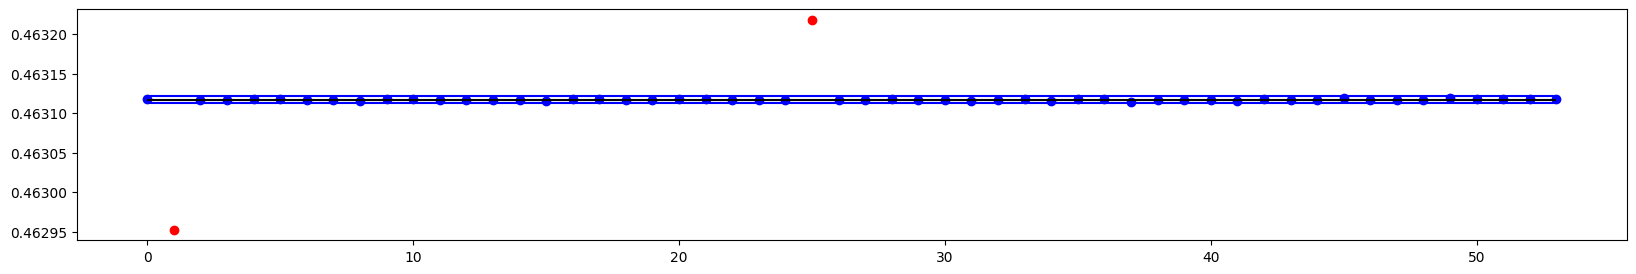

err: 4.48514215e-08  , std: 9.62865848e-07  
err: 6.2949026e-08   , std: 6.55015161e-07  


In [9]:
# Use median and biweight midvariance to remove outliers

time = torch.tensor(range(f.size), dtype=dtype, device=device)

factor = 5.0
center = median(f.frequency)
spread = factor*biweight_midvariance(f.frequency).sqrt()
min_value, max_value = center - spread, center + spread
mask = threshold(f.frequency, min_value, max_value).squeeze(0)

plt.figure(figsize=(20, 3))
plt.scatter(time[~mask].cpu().numpy(), f.frequency[~mask].cpu().numpy(), color='red', marker='o')
plt.scatter(time[mask].cpu().numpy(), f.frequency[mask].cpu().numpy(), color='blue', marker='o')
plt.hlines(center.cpu().numpy(), 0, f.size - 1, color='black')
plt.hlines(center.cpu().numpy() - spread.cpu().numpy(), 0, f.size - 1, color='blue')
plt.hlines(center.cpu().numpy() + spread.cpu().numpy(), 0, f.size - 1, color='blue')
plt.show()

# Mean & variance

f_out = mean(f.frequency[mask])
s_out = variance(f.frequency[mask]).sqrt()
print(f'err: {abs(f_out - f_ref):<16.9}, std: {s_out:<16.9}')

# Weighted mean & variance

weight = 1.0/s**2*torch.stack([spectrum[index] for index, spectrum in zip(f.ffrft_bin.to(torch.int64), f.ffrft_spectrum)])**2
f_out = weighted_mean(f.frequency, weight=weight*mask)
s_out = weighted_variance(f.frequency, weight=weight*mask).sqrt()
print(f'err: {abs(f_out - f_ref):<16.9}, std: {s_out:<16.9}')

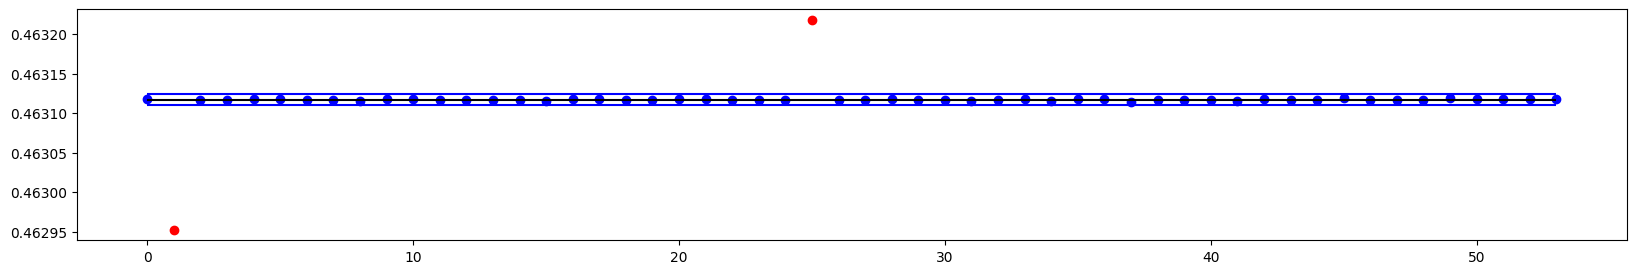

err: 4.48514215e-08  , std: 9.62865848e-07  
err: 6.2949026e-08   , std: 6.55015161e-07  


In [10]:
# Use quantiles to remove outliers

time = torch.tensor(range(f.size), dtype=dtype, device=device)

factor = 5.0
center = median(f.frequency)
value_min, value_max = whiskers(f.frequency, factor=factor)
mask = threshold(f.frequency, min_value, max_value).squeeze(0)

plt.figure(figsize=(20, 3))
plt.scatter(time[~mask].cpu().numpy(), f.frequency[~mask].cpu().numpy(), color='red', marker='o')
plt.scatter(time[mask].cpu().numpy(), f.frequency[mask].cpu().numpy(), color='blue', marker='o')
plt.hlines(center.cpu().numpy(), 0, f.size - 1, color='black')
plt.hlines(value_min.cpu().numpy(), 0, f.size - 1, color='blue')
plt.hlines(value_max.cpu().numpy(), 0, f.size - 1, color='blue')
plt.show()

# Mean & variance

f_out = mean(f.frequency[mask])
s_out = variance(f.frequency[mask]).sqrt()
print(f'err: {abs(f_out - f_ref):<16.9}, std: {s_out:<16.9}')

# Weighted mean & variance

weight = 1.0/s**2*torch.stack([spectrum[index] for index, spectrum in zip(f.ffrft_bin.to(torch.int64), f.ffrft_spectrum)])**2
f_out = weighted_mean(f.frequency, weight=weight*mask)
s_out = weighted_variance(f.frequency, weight=weight*mask).sqrt()
print(f'err: {abs(f_out - f_ref):<16.9}, std: {s_out:<16.9}')

In [11]:
# Estimate the main frequency for sampled signals using 'parabola' interpolation of refined amplitude spectrum
# Estimate noise for each sample, WLS fit to estimate sample spread

# Set data

w = Window(length, 'cosine_window', 1.0, dtype=dtype, device=device)
t = Data.from_data(w, data)

# Sample data

w = Window(512, 'cosine_window', 1.0, dtype=dtype, device=device)
t = Data.from_data(w, torch.cat([t.make_matrix(512, 8, t.work[i]) for i in range(54)]))
n = t.size//54

# Estimate noise for all samples

l = Filter(t)
_, s = l.estimate_noise(limit=32)

# Estimate frequency for each sample

t.window_remove_mean()
t.window_apply()
f = Frequency(t)
f('parabola')
t.reset()

# Set weight

weight = 1.0/s**2*torch.stack([spectrum[index] for index, spectrum in zip(f.ffrft_bin.to(torch.int64), f.ffrft_spectrum)])**2

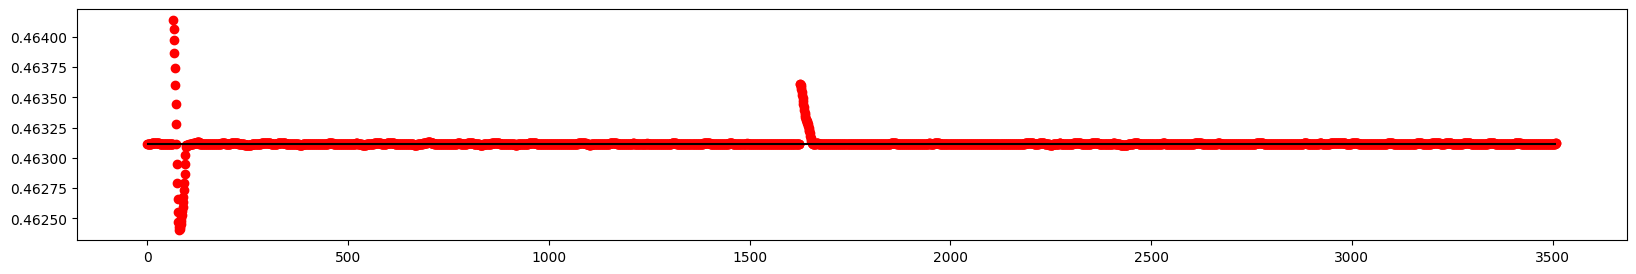

err: 6.06325583e-07  , std: 5.95769741e-05  
err: 3.5082929e-08   , std: 1.99139644e-06  


In [12]:
# Process by samples

# Plot frequencies for each sample

plt.figure(figsize=(20, 3))
plt.scatter(range(f.size), f.frequency.cpu().numpy(), color='red', marker='o')
plt.hlines(f_ref, 0, f.size - 1, color='black')
plt.show()

# Mean & variance

f_out = mean(f.frequency)
s_out = variance(f.frequency).sqrt()
print(f'err: {abs(f_out - f_ref):<16.9}, std: {s_out:<16.9}')

# Weighted mean & variance

f_out = weighted_mean(f.frequency, weight=weight)
s_out = weighted_variance(f.frequency, weight=weight).sqrt()
print(f'err: {abs(f_out - f_ref):<16.9}, std: {s_out:<16.9}')

err: 6.06325583e-07  , std: 1.95491001e-05  
err: 1.00837471e-07  , std: 6.5878347e-07   


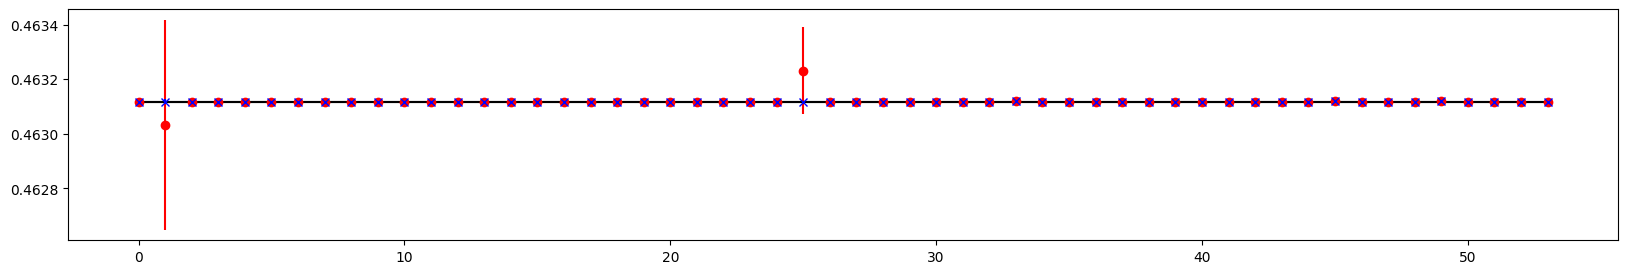

In [13]:
# Process by signals

plt.figure(figsize=(20, 3))

# Mean & variance

f_out = mean(f.frequency.reshape(54, -1))
s_out = variance(f.frequency.reshape(54, -1)).sqrt()

plt.errorbar(range(54), f_out.cpu().numpy(), yerr=s_out.cpu().numpy(), fmt=' ', color='red', marker='o')
plt.hlines(f_ref, 0, 54 - 1, color='black')

f_out, s_out = mean(f_out), variance(f_out).sqrt()
print(f'err: {abs(f_out - f_ref):<16.9}, std: {s_out:<16.9}')

# Weighted mean & variance

f_out = weighted_mean(f.frequency.reshape(54, -1), weight=weight.reshape(54, -1))
s_out = weighted_variance(f.frequency.reshape(54, -1), weight=weight.reshape(54, -1)).sqrt()

plt.errorbar(range(54), f_out.cpu().numpy(), yerr=s_out.cpu().numpy(), fmt=' ', color='blue', marker='x')
plt.hlines(f_ref, 0, 54 - 1, color='black')

f_out, s_out = weighted_mean(f_out, weight=1/s_out**2), weighted_variance(f_out, weight=1/s_out**2).sqrt()
print(f'err: {abs(f_out - f_ref):<16.9}, std: {s_out:<16.9}')

plt.show()

In [14]:
# Data filtering based on (robust) dispecrion can be performed for all samples
# Samples outside the threshold region (or entier signals with such samples) can be removed